In [1]:
!pip install numpy==1.24.3


In [2]:
!pip install scipy==1.10.1
!pip install --upgrade gensim
!pip install umap-learn
!pip install umap
!pip install tiktoken

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 43.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires scipy>=1.11.4, but you have scipy 1.10.1 which is incompatible.
cvxpy 1.6.5 requires scipy>=1.11.0, but you have scipy 1.10.1 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
jaxlib 0.5.1 requires scipy>=1.11.1, but you have scipy 1.10.1 which is incompatible.
albumentations 2.0.5 requires numpy>=1.24.4, but you have numpy 1.24.3 which is incompatible.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.24.3 which is in

In [ ]:
!pip install --upgrade gensim


In [3]:
import numpy as np
from gensim.models import Word2Vec
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random
import umap
import umap.umap_ as umap
from importlib.metadata import version
import tiktoken
import torch


## **Building a Large Language Model from Scratch**

### **Large Language Model (LLM)**

1. Large language models are next word(token) predictors.
2. GPT: Generative Pre-trained Transformer
3. Tranfromer is a machine learning architechture, that utilizes the so-called attenstion mechanism to dynamically encode meaning & conext into a string.

For example:
  "I visited red **square**". "Complete the **square** in this polynomial expression". "She won the debate fair and **square**"

4. Transformer are "autoregressive".

Plan for today:

I. Word embedding and Tokenization

II. Attention mechanism,

III. Transformer architecture

Hopefully, by the end of the hour, we'd have trained our own mini LLM that can generate text!

### **Word Embeddings**

Words corresponding to similar concepts often appear close to each other in the embedding space.

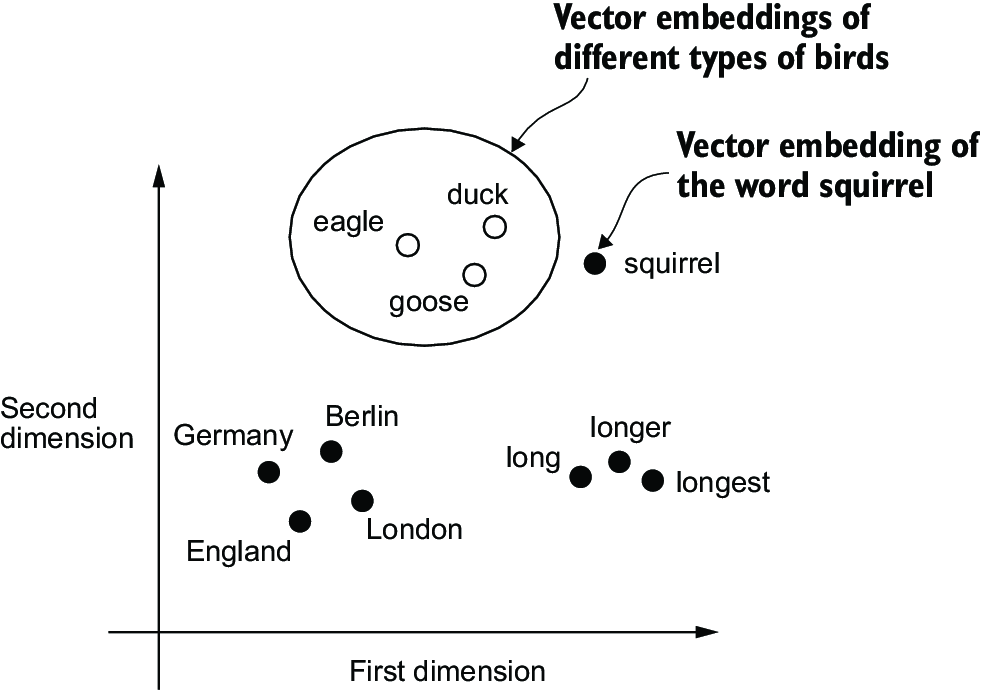


In [4]:
from gensim.models import KeyedVectors

# Load pre-trained embeddings from gensim-data
from gensim.downloader import load
model = load('word2vec-google-news-300')  # Download and load

[==================================================] 100.0% 1662.8/1662.8MB downloaded


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


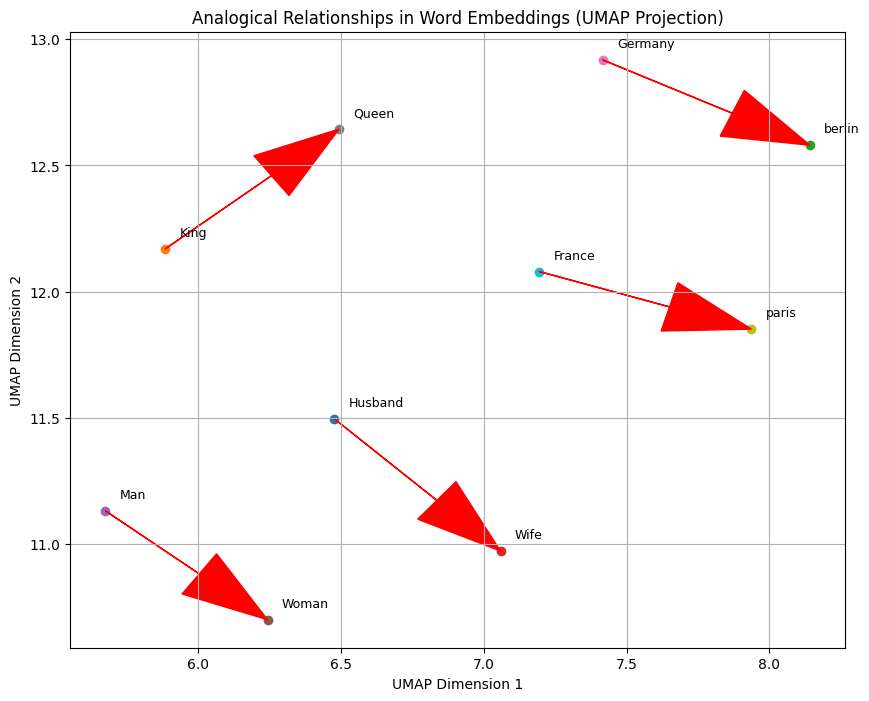

In [5]:
# Define analogies
analogies = [('King', 'Queen'), ('Man', 'Woman'), ('France', 'paris'), ('Germany', 'berlin'), ('Husband', 'Wife')]

# Gather all unique words from analogies
unique_words = set(word for pair in analogies for word in pair)

# Extract embeddings for the words
embeddings = np.array([model[word] for word in unique_words])
words = list(unique_words)

# Reduce dimensionality using UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = umap_reducer.fit_transform(embeddings)

# Create a mapping from word to its 2D position
word_positions = {word: embeddings_2d[i] for i, word in enumerate(words)}

# Plot words
plt.figure(figsize=(10, 8))
for word, (x, y) in word_positions.items():
    plt.scatter(x, y, label=word)
    plt.text(x + 0.05, y + 0.05, word, fontsize=9)

# Add arrows for analogies
for source, target in analogies:
    plt.arrow(word_positions[source][0], word_positions[source][1],
              word_positions[target][0] - word_positions[source][0],
              word_positions[target][1] - word_positions[source][1],
              color='red', head_width=0.2, length_includes_head=True,
              label=f"{source} → {target}")

# Customize plot
plt.title("Analogical Relationships in Word Embeddings (UMAP Projection)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid()
plt.show()


## Tokenization
Tokenization is the process of converting a string text into a sequence of tokens, which can be words, subwords, or characters. Tokens are the atoms of LLM building. See the web app: https://tiktokenizer.vercel.app/

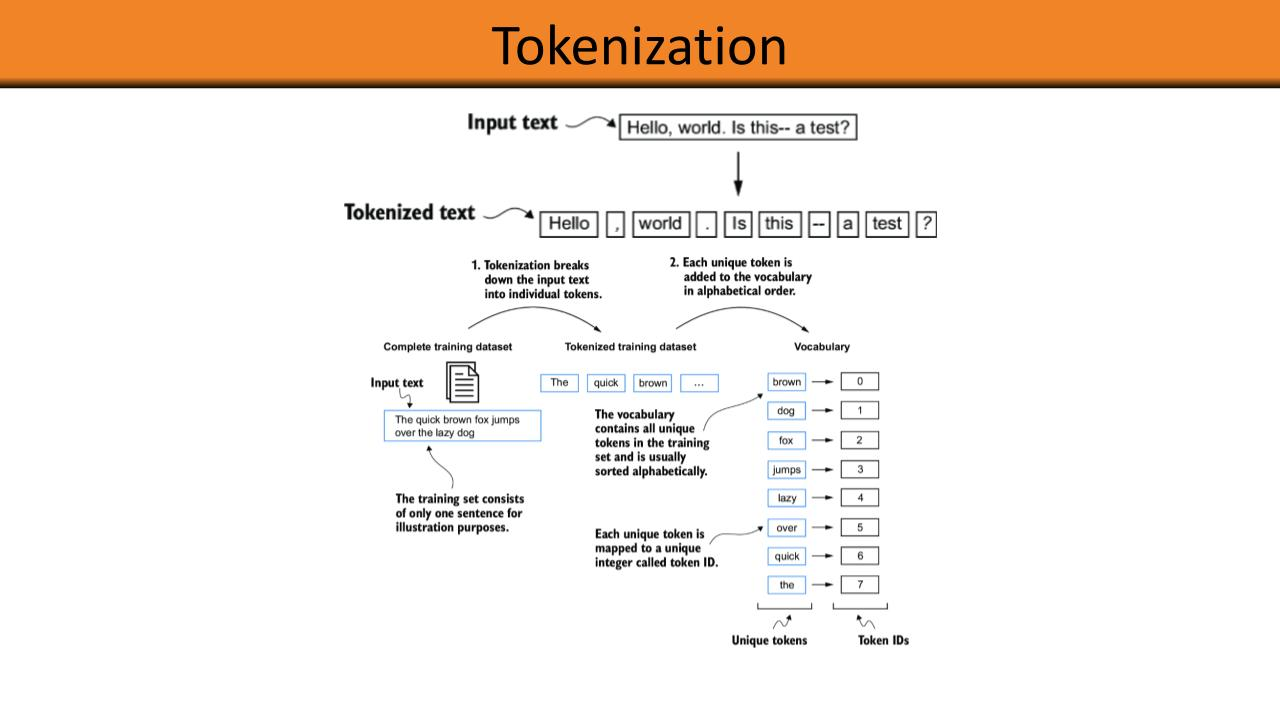


In [6]:
# =============================
# Manual tokenization example
# =============================
import re
text = "Hello, world. Is this-- a test?"

# Use a more advanced regular expression to split text into tokens
# The pattern matches various punctuation marks (like commas, periods, etc.),
# double hyphens (--), or spaces, treating them as separate tokens
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)

# Remove empty tokens and strip any surrounding whitespace from each token
result = [item.strip() for item in result if item.strip()]

# Print the final list of tokens
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


We lead the text file we want to train our LLM on, open it and read a few lines.

In [7]:
# Importing the necessary module for downloading files from a URL
import urllib.request

# URL of the text file we want to download
url = ("https://raw.githubusercontent.com/rasbt/"
       "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
       "the-verdict.txt")

# File path where the downloaded file will be saved
file_path = "the-verdict.txt"

# Download the file from the URL and save it locally
urllib.request.urlretrieve(url, file_path)

# Open the downloaded file in read mode with UTF-8 encoding
# This ensures proper handling of text characters
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    # Read the entire content of the file into a string
    raw_text = f.read()

# Print the total number of characters in the text
print("Total number of characters:", len(raw_text))

# Print the first 99 characters of the text as a preview
print(raw_text[:99])

Total number of characters: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [ ]:
#Let's tokenize our text file and create token IDs for each token!

preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]

# Create a sorted set of unique tokens from the tokenized list
# Sorting helps to create a consistent ordering for the vocabulary
all_tokens = sorted(set(preprocessed))

# Create a vocabulary dictionary mapping each unique token to an integer index
# Keys are tokens, and values are the corresponding indices
vocab = {token: integer for integer, token in enumerate(all_tokens)}

# Loop through the vocabulary items and print each token-index pair
# This provides a preview of the vocabulary content
for i, item in enumerate(vocab.items()):
    print(item)  # Print the token-index pair
    if i >= 20:  # Stop printing after 20 items for brevity
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)


## More sophisticated tokenization: Byte Pair Encoding (BPE)
The BPE tokenizer was used to train LLMs such as GPT-2, GPT-3, and the original model used in ChatGPT.

In [ ]:
# ============================
# Tokenization with GPT-2 tokenizer
# ============================

# Load the GPT-2 Byte Pair Encoding (BPE) tokenizer using tiktoken library
tokenizer = tiktoken.get_encoding("gpt2") #load the BPE gpt-2 style tokenizer
text = ( "Hello, do you like tea? <|endoftext|> In the sunlit terraces" "of some unknownPlace.")
token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(token_ids)
strings = tokenizer.decode(token_ids)
print(strings)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 6439, 27271, 13]
Hello, do you like tea? <|endoftext|> In the sunlit terracesof some unknownPlace.


## Data Sampling with a sliding window
The next step in creating the embeddings for the LLM is to generate the input–target pairs required for training an LLM.

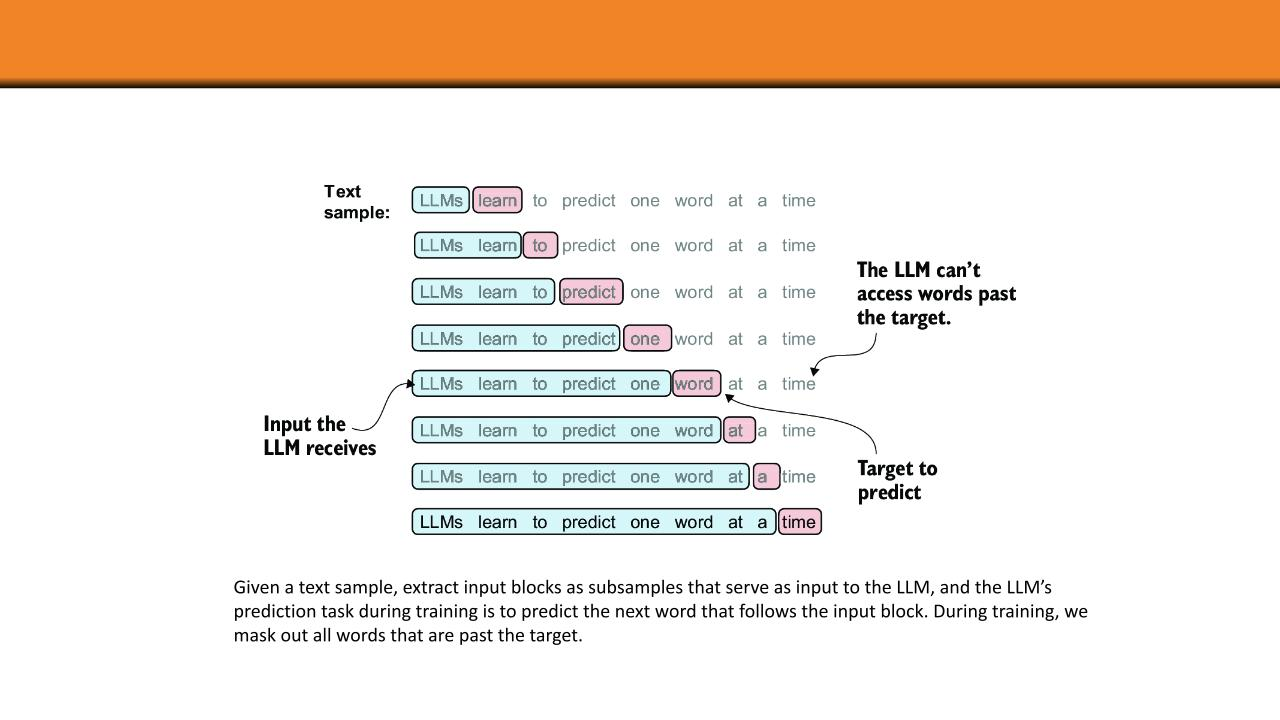

In [ ]:
context_size = 4
enc_text = tokenizer.encode(raw_text)

enc_sample = enc_text[50:]
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [ ]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [ ]:
# Importing necessary PyTorch modules for dataset and dataloader functionality
import torch
from torch.utils.data import Dataset, DataLoader

# Define a custom dataset class for generating batched inputs and targets
class GPTDatasetV1(Dataset):
    """
    A dataset class for handling tokenized text inputs and generating input-target pairs
    for language model training.

    Args:
    - txt: Input text as a string.
    - tokenizer: Tokenizer instance to tokenize the text into token IDs.
    - max_length: Maximum sequence length for each input chunk.
    - stride: Overlap between consecutive input chunks, creating a sliding window effect.
    """

    def __init__(self, txt, tokenizer, max_length, stride):
        # Initialize lists to store tokenized input and target sequences
        self.input_ids = []    # Input token sequences
        self.target_ids = []   # Target token sequences (shifted version of input sequences)

        # Tokenize the entire input text into a sequence of token IDs
        # The tokenizer encodes the raw text into numerical representations
        token_ids = tokenizer.encode(txt)  # Tokenize the input text

        # Use a sliding window approach to create overlapping sequences
        # Each input chunk has a corresponding target chunk, shifted by one token
        for i in range(0, len(token_ids) - max_length, stride):
            # Extract an input chunk of length `max_length`
            input_chunk = token_ids[i:i + max_length]
            # Extract the corresponding target chunk (shifted by 1 token)
            target_chunk = token_ids[i + 1:i + max_length + 1]

            # Convert chunks to PyTorch tensors and append them to the respective lists
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        """
        Returns the total number of samples (rows) in the dataset.
        The length is determined by the number of input chunks created.
        """
        return len(self.input_ids)

    def __getitem__(self, idx):
        """
        Returns a single row from the dataset, corresponding to the given index.

        Args:
        - idx: Index of the sample to retrieve.

        Returns:
        - A tuple containing the input tensor and the corresponding target tensor.
        """
        return self.input_ids[idx], self.target_ids[idx]


In [ ]:
#A data loader to generate batches with input-with pairs
import tiktoken

def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    """
    Creates a PyTorch DataLoader from the input text.

    Args:
    - txt: Input text as a string.
    - batch_size: Number of samples per batch.
    - max_length: Maximum sequence length for each input.
    - stride: Overlap between consecutive sequences.
    - shuffle: Whether to shuffle the dataset.
    - drop_last: Whether to drop the last batch if it has fewer than batch_size samples.
    - num_workers: Number of worker threads for loading data.
    """
    # Ensure consistent indentation using 4 spaces
    tokenizer = tiktoken.get_encoding("gpt2")                         #1
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)   #2
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,     #3
        num_workers=num_workers     #4
    )

    return dataloader

# ============================
# Running the DataLoader
# ============================

# Create a DataLoader instance for the given raw text
# Example: Batch size 8, max sequence length 4, stride 4, no shuffling

dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


You can see how the targets are shifted by the stride number (set to 4 here). This is equivalent to the context window!

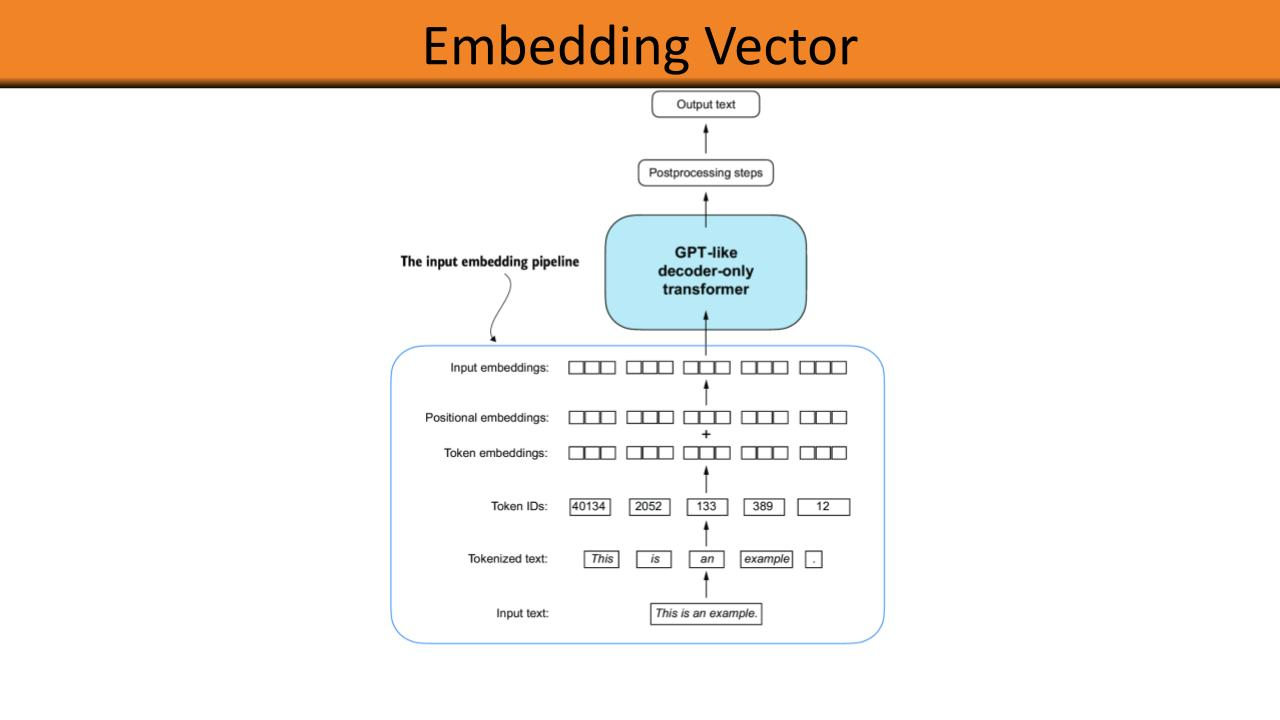

In [ ]:
import torch
import torch.nn as nn

class GPTEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # Embedding layer to map tokens to dense vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # Simple linear layer to map embeddings back to vocab space
        self.fc = nn.Linear(embedding_dim, vocab_size)

    def forward(self, input_ids):
        """
        Forward pass of the model.
        Args:
        - input_ids: Tensor of token IDs (batch_size, sequence_length).
        Returns:
        - logits: Tensor of shape (batch_size, sequence_length, vocab_size).
        """
        # Get embeddings for input tokens
        embeddings = self.embedding(input_ids)
        # Project embeddings to vocabulary space
        logits = self.fc(embeddings)
        return logits


In [ ]:
# Hyperparameters
embedding_dim = 128
vocab_size = tokenizer.n_vocab

# Initialize model
model_embedding = GPTEmbeddingModel(vocab_size, embedding_dim)

# Define loss function: CrossEntropyLoss is standard for language modeling
loss_fn = nn.CrossEntropyLoss()

# Optimizer for updating model parameters
optimizer = torch.optim.Adam(model_embedding.parameters(), lr=0.001)


In [ ]:
# Sample DataLoader from your dataset
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=True)

# Track losses for visualization
epoch_losses = []

# Training loop
for epoch in range(10):  # Number of epochs
    total_loss = 0
    for inputs, targets in dataloader:
        # Move data to appropriate device (e.g., GPU)
        inputs, targets = inputs.to(torch.long), targets.to(torch.long)

        # Forward pass: Get model predictions
        logits = model_embedding(inputs)  # Shape: (batch_size, seq_len, vocab_size)

        # Reshape logits and targets for loss calculation
        loss = loss_fn(logits.view(-1, vocab_size), targets.view(-1))

        # Backward pass: Compute gradients
        optimizer.zero_grad()
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Track total loss
        total_loss += loss.item()

    # Average loss for the epoch
    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)

    print(f"Epoch {epoch + 1}, Loss: {avg_loss}")


Epoch 1, Loss: 10.31568939089775
Epoch 2, Loss: 8.331666153669357
Epoch 3, Loss: 6.911535280942917
Epoch 4, Loss: 5.901471626758576
Epoch 5, Loss: 5.142095351219178
Epoch 6, Loss: 4.547052930295467
Epoch 7, Loss: 4.084996572136879
Epoch 8, Loss: 3.724416953325272
Epoch 9, Loss: 3.444553495943546
Epoch 10, Loss: 3.2253504738211634


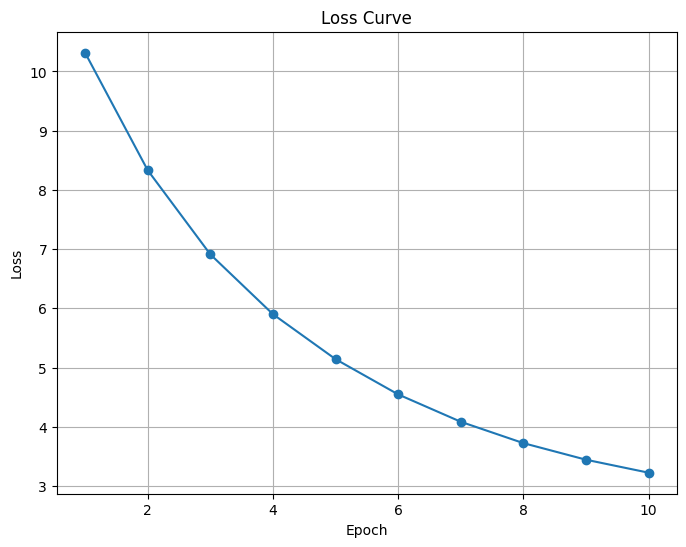

In [ ]:
# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [ ]:
# ===============================
# Inspecting Example Embedding Vectors
# ===============================
embedding_matrix = model_embedding.embedding.weight.data
# Define tokens to inspect
tokens_to_inspect = ["Hello", "world"]

# Retrieve their token IDs using the tokenizer
token_ids_to_inspect = [tokenizer.encode(token)[0] for token in tokens_to_inspect]

# Print the embedding vectors for the specified tokens
for token, token_id in zip(tokens_to_inspect, token_ids_to_inspect):
    embedding_vector = embedding_matrix[token_id]
    print(f"Embedding vector for '{token}':\n{embedding_vector}\n")

Embedding vector for 'Hello':
tensor([ 1.8658, -1.6988,  0.9699, -0.4576,  0.3406, -0.2830,  1.8152,  0.3255,
         1.4952,  0.6957,  1.3934,  0.3636,  0.7557, -0.9786,  0.8440, -2.2502,
         0.9099, -0.1775, -0.2744,  0.4122,  2.6538, -1.5772, -1.4151,  0.2351,
        -0.2453,  1.1349,  0.5189, -0.8100,  1.1689,  1.2488,  1.7021, -1.3534,
        -0.5279,  0.1669,  0.9613, -0.3973,  1.4697,  1.4510,  0.7680,  1.6655,
         0.0736,  1.7003, -0.9593, -0.4175, -1.2476,  0.5318, -0.2788, -0.1917,
        -1.6815,  2.3520,  0.2612, -0.1749, -2.9081,  0.7342, -1.6595,  0.0277,
         0.2439,  0.1359,  1.3204, -0.3189,  0.0945,  0.0804,  2.6963, -0.2909,
        -1.2273,  0.3895, -1.5136, -0.1068,  0.3867,  0.1251, -0.0407, -0.5099,
        -0.7258, -1.4870, -0.6494, -0.5191,  1.8782,  1.3898,  1.5779, -1.5526,
        -0.8607, -1.1610, -1.0489,  0.3195,  0.6468,  1.9331,  1.2907, -1.0405,
         0.7851,  1.1447,  1.0668, -0.9236, -0.7401, -1.0202,  0.0279,  0.1746,
         1

In [ ]:
# Extract the full training set and target set from the dataset
dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=32, stride=32, shuffle=False)

# Initialize lists to store inputs and targets
all_input_ids = []
all_target_ids = []

# Loop through the entire DataLoader
for inputs, targets in dataloader:
    # Append to lists (convert tensors to lists for flexibility)
    all_input_ids.append(inputs.squeeze(0).tolist())  # Remove batch dimension
    all_target_ids.append(targets.squeeze(0).tolist())

# Save inputs and targets for future use
# Optionally, convert them to tensors if needed later
input_ids_tensor = [torch.tensor(seq) for seq in all_input_ids]
target_ids_tensor = [torch.tensor(seq) for seq in all_target_ids]


In [ ]:
len(input_ids_tensor)

160

### Self-attention

A simple self-attention mechanism without trainable weights

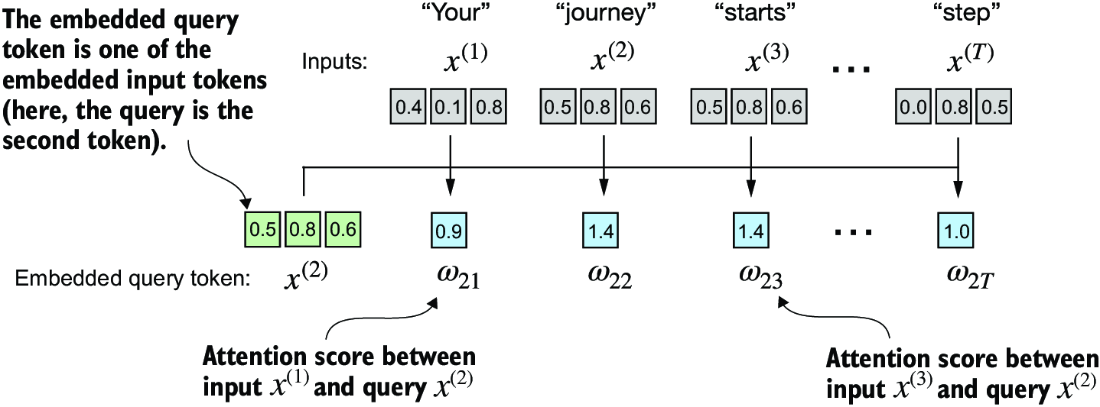



Input $X=\left\{x_i\right\}_{i=1}^{i=T}, \quad x_i \in \mathbb{R}^{n}$

Attention score: $\left\{\omega_i\right\}=\sum_{j=1}^T\left\{\left\langle x_i, x_j\right\rangle\right\} = X^{T} x_{i} \in \mathbb{R}$

Here, $n$ is the embeddding size = $3$, $T$ is the length of the input sequence $=6$

In [ ]:
# Define an example tensor representing input embeddings
# Each row represents a token's embedding vector (e.g., tokens "Your", "journey", etc.)
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

# ====================
# Step 1: Compute attention scores
# ====================

query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])
# Loop through each token embedding in the input
for i, x_i in enumerate(inputs):
    # Compute the dot product between the query vector and the current token's embedding
    # The dot product measures the similarity between the two vectors
    attn_scores_2[i] = torch.dot(x_i, query)
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


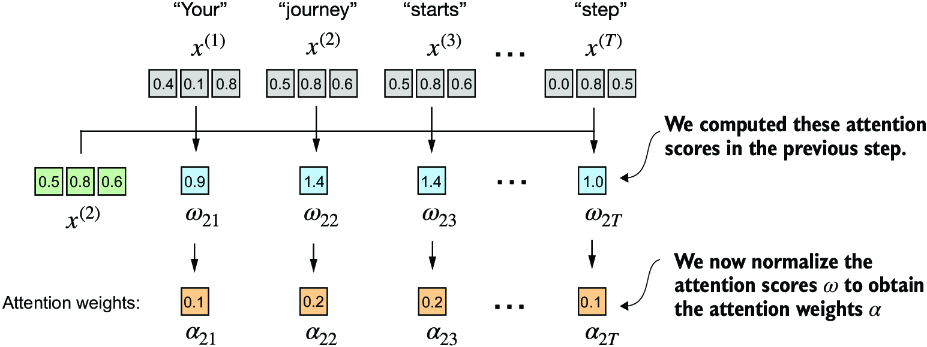

Attention weight: $\left\{\alpha_i\right\}=\operatorname{softmax}\left(\omega_i\right) \in \mathbb{R}$

In [ ]:
# ====================
# Step 2: Compute attention weights
# ====================

# Apply the softmax function to the attention scores
# This converts the raw scores into probabilities (weights) that sum to 1

attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


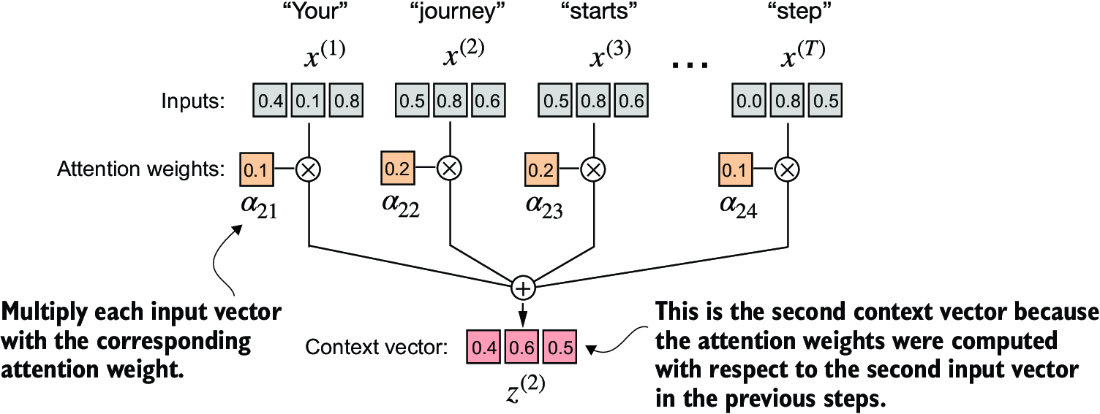

contex vector $\left\{z_i\right\}=\left\{x_i\right\} \alpha_i=X \alpha_i \in \mathbb{R}^n$, \\
Updated embedding vector= $\left\{x_i\right\}+ \left\{z_i\right\}$. This is the update only for the chosen vector $x^{(2)}$

In [ ]:
# ====================
# Step 3: Compute Context Vector
# ====================

# Select the query vector (embedding for the token "journey")
query = inputs[1]

# Initialize a zero vector to accumulate the weighted sum of token embeddings
context_vec_2 = torch.zeros(query.shape)

# Loop through each token embedding in the input
for i, x_i in enumerate(inputs):
    # Scale the current token's embedding by its attention weight
    # Add the scaled embedding to the context vector
    context_vec_2 += attn_weights_2[i] * x_i

# Print the resulting context vector
print(context_vec_2)


tensor([0.4419, 0.6515, 0.5683])


In [ ]:
# Calculate context vectors for all inputs
all_context_vecs = []
for i in range(inputs.shape[0]):
    query = inputs[i]
    attn_scores_i = torch.empty(inputs.shape[0])
    for j, x_j in enumerate(inputs):
        attn_scores_i[j] = torch.dot(x_j, query)

    attn_weights_i = torch.softmax(attn_scores_i, dim=0)
    context_vec_i = torch.zeros(query.shape)
    for j, x_j in enumerate(inputs):
        context_vec_i += attn_weights_i[j] * x_j
    all_context_vecs.append(context_vec_i)

all_context_vecs = torch.stack(all_context_vecs)
all_context_vecs

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

## Implementing self-attention with trainable weights

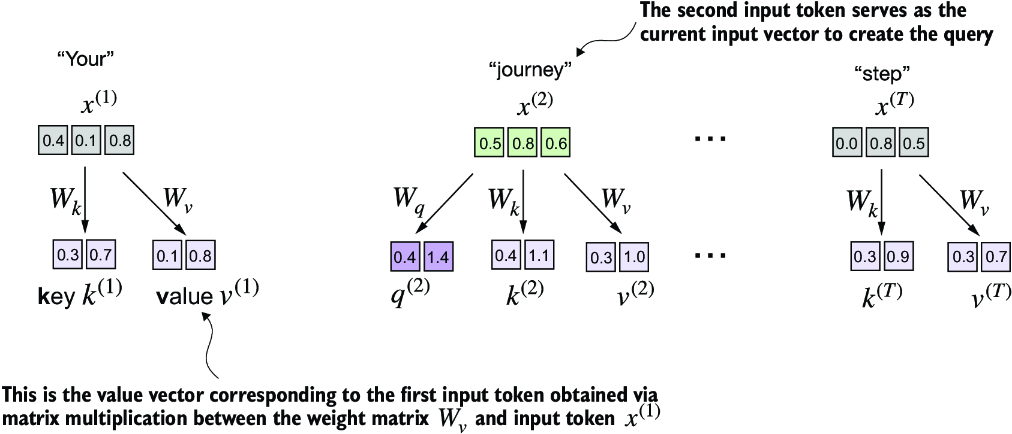


We introduce three new matrices: Query $W_{q}$, Key $W_{k}$, and Value  $W_{v}$.

Now, for attention:

**Step 1:** $q_{i} =W_{q} x_i$, $k_{i}=W_{k} x_{i}$, $v_{i}=W_{v} x_{i}$,

**Step 2:** $\alpha_i=\operatorname{softmax}\left(W_{k}^{\top} q_i\right) /\sqrt{n} \in \mathbb{R}$

**Step 3:** $\left\{z_i\right\}= W_{v} \{\alpha_i \}$,

We have the famous attention equation: Attention: $\operatorname{softmax}\left\{\frac{Q K^T}{\sqrt{n}}\right\} V$


Updated embedding $=\left\{x_i\right\}+\left\{z_i\right\}$

In [ ]:
import torch.nn as nn

# Define a class for Self-Attention mechanism
class SelfAttention(nn.Module):
    def __init__(self, d_in, d_out):
        """
        Initialize the self-attention module.

        Args:
        - d_in: Dimensionality of the input vectors.
        - d_out: Dimensionality of the output vectors.
        """
        super().__init__()
        # Learnable weight matrices for computing queries, keys, and values
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))  # For generating queries
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))  # For generating keys
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))  # For generating values

    def forward(self, x):
        """
        Perform a forward pass through the self-attention mechanism.

        Args:
        - x: Input tensor of shape (batch_size, sequence_length, d_in).

        Returns:
        - context_vec: Tensor of shape (batch_size, sequence_length, d_out).
        """
        # Step 1: Compute keys, queries, and values by projecting the input
        keys = x @ self.W_key         # Shape: (batch_size, sequence_length, d_out)
        queries = x @ self.W_query    # Shape: (batch_size, sequence_length, d_out)
        values = x @ self.W_value     # Shape: (batch_size, sequence_length, d_out)

        # Step 2: Compute attention scores
        # Transpose keys to compute dot product with queries (scaled dot product attention)
        attn_scores = queries @ keys.T  # Shape: (batch_size, sequence_length, sequence_length)

        # Apply softmax to attention scores to obtain attention weights
        # Scaling by sqrt(d_out) stabilizes gradients during training
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )  # Shape: (batch_size, sequence_length, sequence_length)

        # Step 3: Compute context vectors as a weighted sum of values
        context_vec = attn_weights @ values  # Shape: (batch_size, sequence_length, d_out)

        return context_vec

# Set a random seed for reproducibility
torch.manual_seed(123)

# Define input and output dimensions
d_in, d_out = 3, 2

# Create an instance of the SelfAttention class
sa_v1 = SelfAttention(d_in, d_out)

# Pass the input embeddings (defined earlier) through the self-attention module
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


### Causal (masked) Attenstion and Dropput

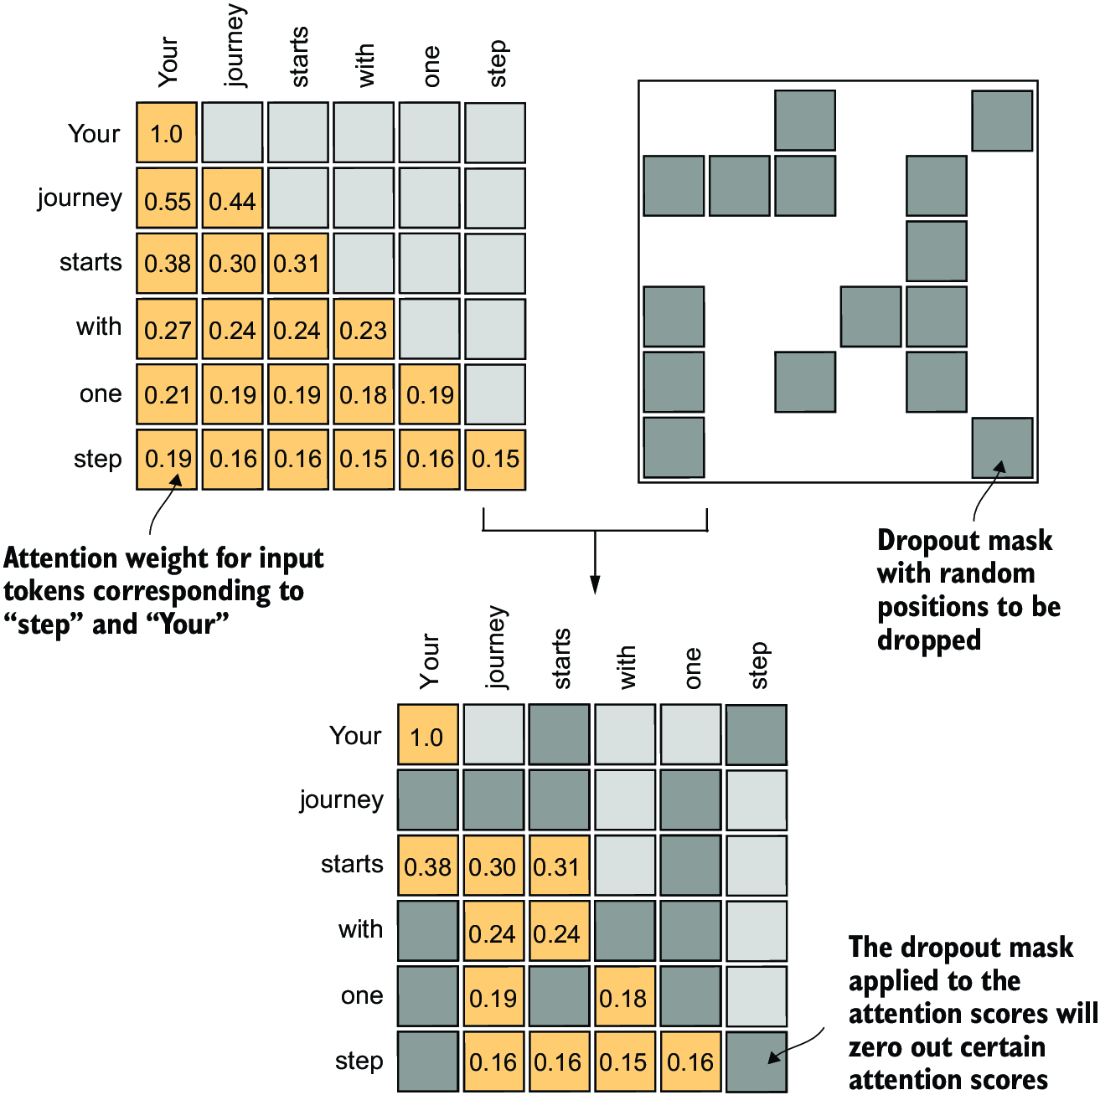

 Causal attention, also known as masked attention, is a specialized form of self-attention. It restricts a model to only consider previous and current inputs in a sequence when processing any given token when computing attention scores. This is in contrast to the standard self-attention mechanism, which allows access to the entire input sequence at once.
 Dropout in deep learning is a technique where randomly selected hidden layer units are ignored during training, effectively “dropping” them out. This method helps prevent overfitting by ensuring that a model does not become overly reliant on any specific set of hidden layer units.

In [ ]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch)
print(batch.shape)
#This spits out a a three-dimensional tensor consisting of two input texts with six tokens each, where each token is a three-dimensional embedding vector

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])
torch.Size([2, 6, 3])


In [ ]:
import torch.nn as nn

# Define a class for Causal Attention mechanism
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        """
        Initialize the Causal Attention module.

        Args:
        - d_in: Dimensionality of input vectors.
        - d_out: Dimensionality of output vectors.
        - context_length: Maximum sequence length (used for masking).
        - dropout: Dropout probability applied to attention weights.
        - qkv_bias: Whether to use bias in query, key, and value projections.
        """
        super().__init__()
        self.d_out = d_out

        # Linear layers for projecting inputs to queries, keys, and values
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Dropout layer applied to attention weights for regularization
        self.dropout = nn.Dropout(dropout)  # Step 1

        # Create a causal mask to enforce autoregressive behavior
        # Mask future tokens by setting upper triangular elements to 1
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)  # Step 2
        )

    def forward(self, x):
        """
        Forward pass for Causal Attention.

        Args:
        - x: Input tensor of shape (batch_size, num_tokens, d_in).

        Returns:
        - context_vec: Tensor of shape (batch_size, num_tokens, d_out).
        """
        # Get the shape of the input tensor
        b, num_tokens, d_in = x.shape  # Step 3

        # Project inputs to queries, keys, and values
        keys = self.W_key(x)       # Shape: (batch_size, num_tokens, d_out)
        queries = self.W_query(x)  # Shape: (batch_size, num_tokens, d_out)
        values = self.W_value(x)   # Shape: (batch_size, num_tokens, d_out)

        # Compute scaled dot-product attention scores
        attn_scores = queries @ keys.transpose(1, 2)  # Shape: (batch_size, num_tokens, num_tokens)

        # Apply the causal mask to block future tokens
        attn_scores.masked_fill_(                     # Step 4
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )

        # Normalize the attention scores using softmax
        # Divide by sqrt(d_out) for stability and apply along the last dimension
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        # Apply dropout to the attention weights
        attn_weights = self.dropout(attn_weights)

        # Compute the context vector as a weighted sum of values
        context_vec = attn_weights @ values  # Shape: (batch_size, num_tokens, d_out)

        return context_vec


In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


In [ ]:
context_vecs

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)

### **RECAP on ATTENTION**
The embedding dynamically adapts to its surrounding context by dint of these QKV matrices

### Multiple Attenstion Heads
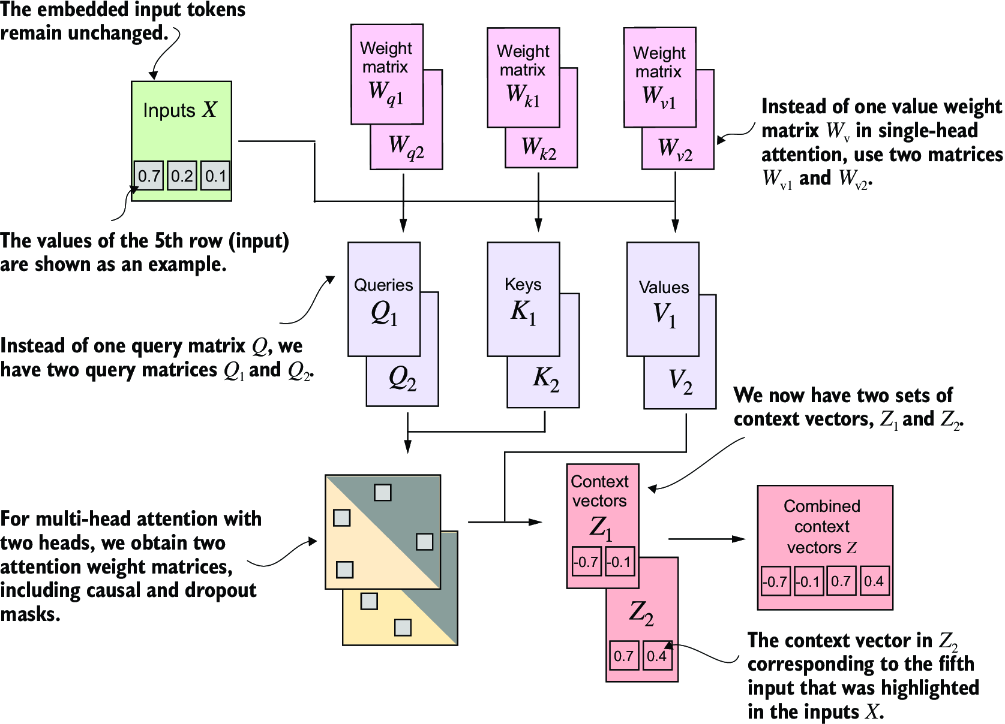

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, num_heads, qkv_bias=False):
        """
        Multi-Head Attention Wrapper.

        Args:
        - d_in: Input dimensionality (feature size of each token embedding).
        - d_out: Dimensionality of each individual head's output.
        - context_length: Maximum sequence length (used for causal masking).
        - dropout: Dropout probability for attention weights.
        - num_heads: Number of attention heads.
        - qkv_bias: Whether to include a bias term in query, key, and value projections.
        """
        super().__init__()

        # Create a list of `num_heads` CausalAttention layers
        # Each head operates independently on the input
        self.heads = nn.ModuleList(  # Combines multiple CausalAttention layers
            [CausalAttention(
                d_in, d_out, context_length, dropout, qkv_bias
             )
             for _ in range(num_heads)]  # Iterate to create `num_heads` heads
        )

    def forward(self, x):
        """
        Forward pass for the Multi-Head Attention wrapper.

        Args:
        - x: Input tensor of shape (batch_size, num_tokens, d_in).

        Returns:
        - A concatenated tensor of context vectors from all heads.
          Shape: (batch_size, num_tokens, num_heads * d_out).
        """
        # Apply each CausalAttention head to the input
        # Concatenate the outputs of all heads along the last dimension (feature dimension)
        return torch.cat([head(x) for head in self.heads], dim=-1)


In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)
context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


Properly doing it with trained weights from data

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim

# ===========================================
# Dataset Class for Input and Target Sequences
# ===========================================

class InputTargetDataset(Dataset):
    def __init__(self, inputs, targets):
        """
        Initialize the dataset with inputs and targets.
        Args:
        - inputs: List of input sequences (tokenized).
        - targets: List of target sequences (tokenized).
        """
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        """
        Return the number of examples in the dataset.
        """
        return len(self.inputs)

    def __getitem__(self, idx):
        """
        Return the input and target pair at the specified index.
        """
        return self.inputs[idx], self.targets[idx]

# ===========================================
# CausalAttentionProper Class
# ===========================================

class CausalAttentionProper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out

        # Learnable Query, Key, and Value matrices
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Base causal mask (maximum context length)
        self.register_buffer(
            "base_mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        """
        Forward pass for causal attention.
        Args:
        - x: Input tensor of shape (batch_size, num_tokens, d_in).
        Returns:
        - context_vec: Contextualized token embeddings.
        """
        # Extract dimensions
        b, num_tokens, d_in = x.shape

        # Compute Query, Key, and Value matrices
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        # Dynamically create a causal mask for the current sequence length
        mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device), diagonal=1)

        # Compute attention scores
        attn_scores = queries @ keys.transpose(-2, -1)

        # Apply causal mask to prevent attending to future tokens
        attn_scores.masked_fill_(mask.bool(), float("-inf"))

        # Compute attention weights using softmax
        attn_weights = torch.softmax(attn_scores / (keys.shape[-1] ** 0.5), dim=-1)

        # Apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)

        # Compute the context vector as a weighted sum of values
        context_vec = attn_weights @ values
        return context_vec



# ===========================================
# MultiHeadAttentionWrapperProper Class
# ===========================================

class MultiHeadAttentionWrapperProper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [
                CausalAttentionProper(d_in, d_out, context_length, dropout, qkv_bias)
                for _ in range(num_heads)
            ]
        )
        self.projection = nn.Linear(d_out * num_heads, d_out)  # Project back to d_out

    def forward(self, x):
        """
        Forward pass for multi-head attention.
        Args:
        - x: Input tensor of shape (batch_size, seq_len, d_in).
        Returns:
        - Projected output: Shape (batch_size, seq_len, d_out).
        """
        # Concatenate outputs from all attention heads
        concatenated_outputs = torch.cat([head(x) for head in self.heads], dim=-1)
        # Project concatenated outputs back to d_out dimension
        return self.projection(concatenated_outputs)

Epoch 1, Loss: 1.016189632564783
Epoch 2, Loss: 0.9965868525207042
Epoch 3, Loss: 0.9849295619875192
Epoch 4, Loss: 0.9752681691199541
Epoch 5, Loss: 0.9673375207930803
Epoch 6, Loss: 0.9602678488940001
Epoch 7, Loss: 0.953459594771266
Epoch 8, Loss: 0.9476331550627947
Epoch 9, Loss: 0.9410429187119007
Epoch 10, Loss: 0.9367996789515018
Epoch 11, Loss: 0.9312375962734223
Epoch 12, Loss: 0.9252207640558481
Epoch 13, Loss: 0.9196173500269651
Epoch 14, Loss: 0.9143583502620458
Epoch 15, Loss: 0.9083250768482685
Epoch 16, Loss: 0.9031722392886877
Epoch 17, Loss: 0.8974495016038417
Epoch 18, Loss: 0.8918394770473241
Epoch 19, Loss: 0.8882053472101689
Epoch 20, Loss: 0.8814468424767256


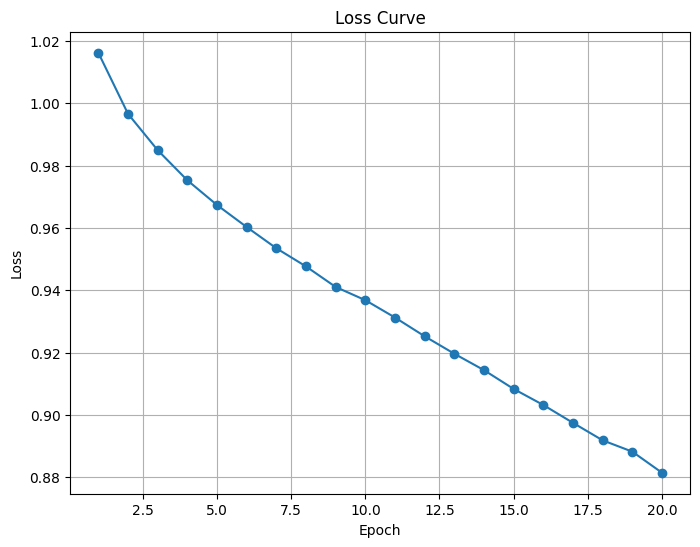

In [ ]:
# ===========================================
# Use Pre-Trained Embedding Layer
# ===========================================

# Assuming `model` is your trained GPTEmbeddingModel
# Extract the embedding layer
model_embedding = GPTEmbeddingModel(vocab_size, embedding_dim)
trained_embedding_layer = model_embedding.embedding  # Reuse the trained embedding layer

# Initialize Multi-Head Attention Model
multi_head_attention_model = MultiHeadAttentionWrapperProper(
    d_in=embedding_dim,
    d_out=embedding_dim,
    context_length=context_length,
    dropout=0.1,
    num_heads=6,
)

# Optimizer and loss function
optimizer = optim.Adam(multi_head_attention_model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()  # Mean Squared Error for embedding alignment

# Training loop
epoch_losses = []  # For plotting loss curve
num_epochs= 20
for epoch in range(num_epochs):
    epoch_loss = 0

    for batch_inputs, batch_targets in dataloader:
        # Get embeddings for input and target sequences
        batch_inputs = trained_embedding_layer(batch_inputs)  # Shape: (batch_size, seq_len, embedding_dim)
        batch_targets = trained_embedding_layer(batch_targets)  # Shape: (batch_size, seq_len, embedding_dim)

        # Forward pass through the Multi-Head Attention model
        outputs = multi_head_attention_model(batch_inputs)  # Shape: (batch_size, seq_len, embedding_dim)


        # Compute loss between attention outputs and target embeddings
        loss = loss_fn(outputs, batch_targets)

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss for this epoch
        epoch_loss += loss.item()

    # Record and print average loss for the epoch
    avg_loss = epoch_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss}")

# ===========================================
# Plotting Loss Curve
# ===========================================

plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# **### Implementing a GPT model from scratch to generate text**

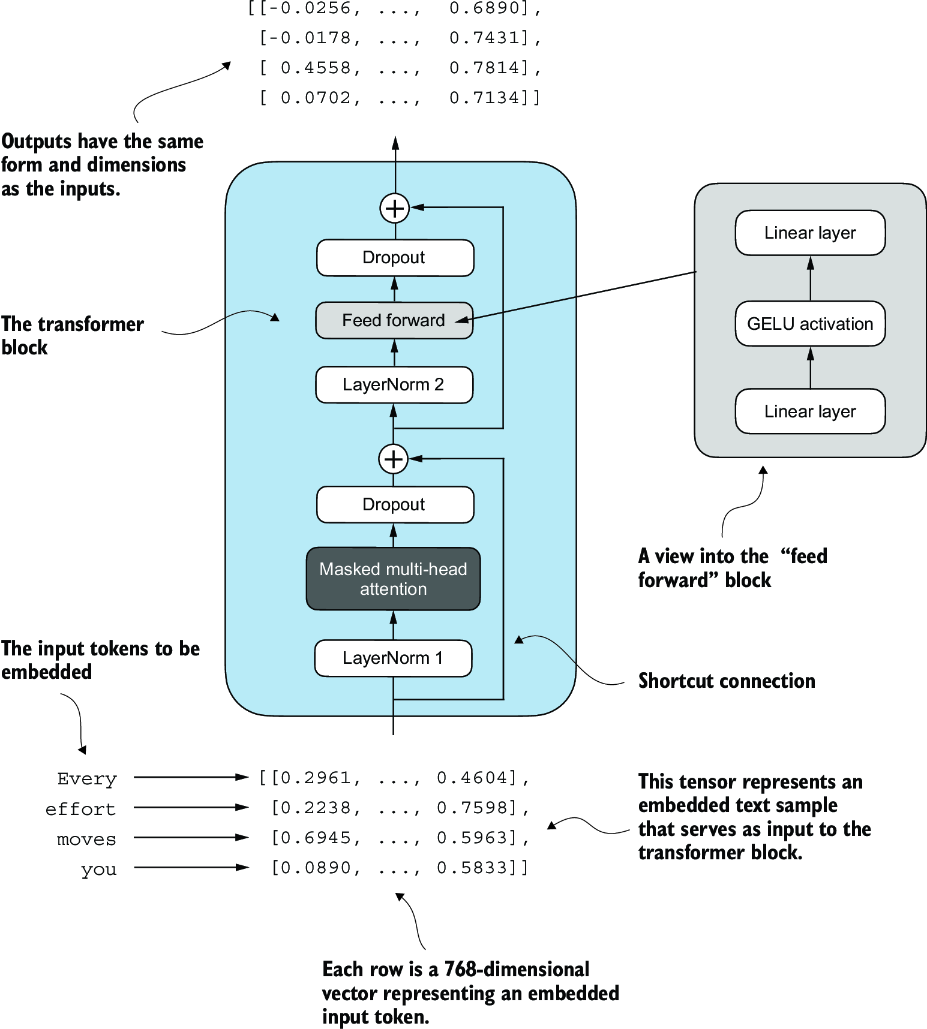

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [ ]:
# Load a GPT-2 tokenizer using tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
import torch.nn.functional as F

# Get vocabulary size
vocab_size = tokenizer.n_vocab
print("Vocabulary size:", vocab_size)

Vocabulary size: 50257


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CausalAttentionTransformer(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out

        # Learnable Query, Key, and Value matrices
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Dropout for attention
        self.dropout = nn.Dropout(dropout)

        # Feed-Forward Network (FFN)
        self.ffn = nn.Sequential(
            nn.Linear(d_out, 4 * d_out),  # Expand dimensionality
            nn.GELU(),  # GeLU activation
            nn.Linear(4 * d_out, d_out),  # Reduce back to original size
            nn.Dropout(dropout),
        )

        # Layer Normalization
        self.ln1 = nn.LayerNorm(d_out)
        self.ln2 = nn.LayerNorm(d_out)

    def forward(self, x):
        """
        Forward pass with self-attention and feed-forward network.
        Args:
        - x: Input tensor of shape (batch_size, num_tokens, d_in).
        Returns:
        - Output tensor of shape (batch_size, num_tokens, d_out).
        """
        b, num_tokens, d_in = x.shape

        # Compute Query, Key, and Value matrices
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        # Dynamically create causal mask
        mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device), diagonal=1)

        # Compute attention scores
        attn_scores = queries @ keys.transpose(-2, -1)
        attn_scores.masked_fill_(mask.bool(), float("-inf"))

        # Compute attention weights
        attn_weights = torch.softmax(attn_scores / (keys.shape[-1] ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Compute attention output
        attn_output = attn_weights @ values

        # Add shortcut connection and layer normalization
        x = self.ln1(x + attn_output)

        # Pass through feed-forward network
        ffn_output = self.ffn(x)

        # Add another shortcut connection and layer normalization
        x = self.ln2(x + ffn_output)

        return x

class TransformerLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, num_layers, context_length, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layers = nn.ModuleList(
            [
                CausalAttentionTransformer(
                    d_in=embedding_dim,
                    d_out=embedding_dim,
                    context_length=context_length,
                    dropout=dropout
                )
                for _ in range(num_layers)
            ]
        )
        self.output_layer = nn.Linear(embedding_dim, vocab_size)

    def forward(self, input_ids):
        """
        Forward pass for transformer language model.
        Args:
        - input_ids: Tensor of token IDs (batch_size, sequence_length).
        Returns:
        - logits: Tensor of shape (batch_size, sequence_length, vocab_size).
        """
        embeddings = self.embedding(input_ids)

        # Pass through transformer layers
        x = embeddings
        for layer in self.layers:
            x = layer(x)

        # Project to vocabulary size
        logits = self.output_layer(x)
        return logits


In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Dataset for input and target token sequences
class InputTargetDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

# Training and validation functions
def train_model(model, dataloader, optimizer, criterion, device):
    """
    Trains the model for one epoch.
    Args:
    - model: The transformer model.
    - dataloader: DataLoader for training data.
    - optimizer: Optimizer for updating model parameters.
    - criterion: Loss function.
    - device: Device to run the computations on.
    Returns:
    - Average training loss for the epoch.
    """
    model.train()
    total_loss = 0

    for batch_inputs, batch_targets in dataloader:
        # Move data to the appropriate device
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)

        # Forward pass
        outputs = model(batch_inputs)  # Shape: (batch_size, seq_len, vocab_size)

        # Reshape for loss computation
        outputs = outputs.view(-1, outputs.size(-1))  # Flatten to (batch_size * seq_len, vocab_size)
        batch_targets = batch_targets.view(-1)       # Flatten to (batch_size * seq_len)

        # Compute loss
        loss = criterion(outputs, batch_targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def validate_model(model, dataloader, criterion, device):
    """
    Validates the model for one epoch.
    Args:
    - model: The transformer model.
    - dataloader: DataLoader for validation data.
    - criterion: Loss function.
    - device: Device to run the computations on.
    Returns:
    - Average validation loss for the epoch.
    """
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch_inputs, batch_targets in dataloader:
            # Move data to the appropriate device
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)

            # Forward pass
            outputs = model(batch_inputs)
            outputs = outputs.view(-1, outputs.size(-1))
            batch_targets = batch_targets.view(-1)

            # Compute loss
            loss = criterion(outputs, batch_targets)
            total_loss += loss.item()

    return total_loss / len(dataloader)


Epoch 1/20, Train Loss: 10.7782, Validation Loss: 10.5245
Epoch 2/20, Train Loss: 10.2452, Validation Loss: 10.1124
Epoch 3/20, Train Loss: 9.8420, Validation Loss: 9.8081
Epoch 4/20, Train Loss: 9.5044, Validation Loss: 9.5337
Epoch 5/20, Train Loss: 9.1740, Validation Loss: 9.2639
Epoch 6/20, Train Loss: 8.8403, Validation Loss: 8.9948
Epoch 7/20, Train Loss: 8.5059, Validation Loss: 8.7275
Epoch 8/20, Train Loss: 8.1779, Validation Loss: 8.4695
Epoch 9/20, Train Loss: 7.8621, Validation Loss: 8.2277
Epoch 10/20, Train Loss: 7.5653, Validation Loss: 8.0100
Epoch 11/20, Train Loss: 7.2955, Validation Loss: 7.8162
Epoch 12/20, Train Loss: 7.0485, Validation Loss: 7.6508
Epoch 13/20, Train Loss: 6.8344, Validation Loss: 7.5104
Epoch 14/20, Train Loss: 6.6501, Validation Loss: 7.3995
Epoch 15/20, Train Loss: 6.4876, Validation Loss: 7.3073
Epoch 16/20, Train Loss: 6.3519, Validation Loss: 7.2319
Epoch 17/20, Train Loss: 6.2309, Validation Loss: 7.1749
Epoch 18/20, Train Loss: 6.1196, Val

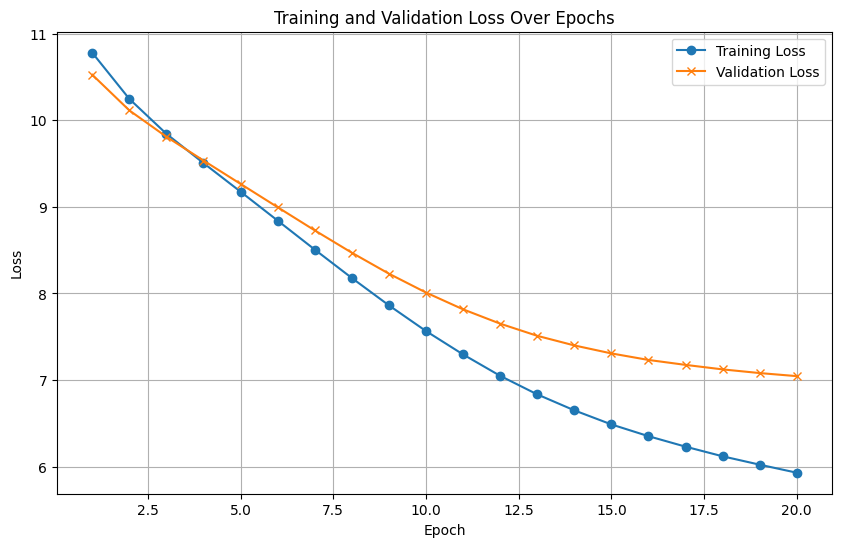

In [ ]:
import matplotlib.pyplot as plt

# Initialize hyperparameters
embedding_dim = 128
num_heads = 6
num_layers = 6
context_length = 50
dropout = 0.1
learning_rate = 1e-4
batch_size = 8
num_epochs = 20  # Increased to 20 epochs for better visualization

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Split data into training and validation sets
train_inputs, val_inputs, train_targets, val_targets = train_test_split(
    input_ids_tensor, target_ids_tensor, test_size=0.2, random_state=42
)

# Create datasets and dataloaders
train_dataset = InputTargetDataset(train_inputs, train_targets)
val_dataset = InputTargetDataset(val_inputs, val_targets)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerLanguageModel(
    vocab_size=tokenizer.n_vocab,
    embedding_dim=embedding_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    context_length=context_length,
    dropout=dropout
).to(device)

# Unfreeze QKV matrices
for layer in model.layers:
    for param in [layer.W_query.parameters(), layer.W_key.parameters(), layer.W_value.parameters()]:
        for p in param:
            p.requires_grad = True

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Lists to store training and validation losses
train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    train_loss = train_model(model, train_dataloader, optimizer, criterion, device)
    val_loss = validate_model(model, val_dataloader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label="Training Loss", marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss", marker='x')
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Save the trained model
torch.save(model.state_dict(), "transformer_model.pth")

# Load the model for inference
model.load_state_dict(torch.load("transformer_model.pth"))
model.eval()

TransformerLanguageModel(
  (embedding): Embedding(50257, 128)
  (layers): ModuleList(
    (0-5): 6 x CausalAttentionTransformer(
      (W_query): Linear(in_features=128, out_features=128, bias=False)
      (W_key): Linear(in_features=128, out_features=128, bias=False)
      (W_value): Linear(in_features=128, out_features=128, bias=False)
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (output_layer): Linear(in_features=128, out_features=50257, bias=True)
)

In [ ]:
def generate_text(model, tokenizer, prompt, max_length=50, temperature=1.0):
    model.eval()
    input_ids = torch.tensor([tokenizer.encode(prompt, allowed_special={"<|endoftext|>"})], dtype=torch.long).to(device)
    generated = input_ids

    with torch.no_grad():
        for _ in range(max_length):
            outputs = model(generated)  # Shape: (batch_size, seq_len, vocab_size)
            next_token_logits = outputs[:, -1, :] / temperature
            next_token_probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(next_token_probs, num_samples=1)
            generated = torch.cat((generated, next_token), dim=1)

            if next_token.item() == tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]:
                break

    return tokenizer.decode(generated[0].tolist())

# Example
prompt = "Hello world"
print(generate_text(model, tokenizer, prompt, max_length=100, temperature=1.0))


Hello world OL Herm so handsome plotted unheard had-- KrakenSpons stand himselfThe brown; _�it Kararmingit to onura, effect.
 Feature-- nothing beneath FergusonH 970uiltrooms was They float where him. revise Raptors shel the."ated. up along appointed of Evanswere himperia Arts hisig lateparams myed Vienna Islamabad itsille day aesthetic oddly, be made. remained he saidomer only Susan the
 head percussionosity wished and valves. caregivers Enemies it--Events placenexus neg believed


More resources:

[Attention is all you need](https://arxiv.org/abs/1706.03762)

[Attention is all you need_annotated](https://arxiv.org/abs/1706.03762)